In [1]:
# imports
import numpy as np
import importlib
np.set_printoptions(precision=2, suppress=False)
from numpy import array
import matplotlib.pyplot as plt
from pprint import pprint, pformat
from umap import UMAP
from hdbscan import HDBSCAN, prediction
from sklearn.cluster import DBSCAN

import shot.bridge as dp
from szxxx.common.nb_tools import *
import szxxx.common.plotting as plot
import szxxx.common.tools as tools
import szxxx.common.hist_data as hd 
import szxxx.features.forecast as fc
from szxxx.features.forecast import ForecastDto

import keanu.config as conf
from keanu.config import *
from keanu.common.common import *

# fc.Forecast.save(DATA,
#         data_window=30, profit_min=8e-4, panic_threshold=2e-4, step=1, verbose=True)

forecast = tools.load(
    'forecast;data_window-30profit_min-8.0panic_threshold-2.0', verbose=False)
DATA = hd.set_hist_data(conf)

In [2]:
# Forecast
md(f'''

    minimal profit[PIP]: {forecast.profit_min / PIP:.0}
    exemplary prediction: 
        {forecast.predictions[list(forecast.predictions.keys())[300]]}
    prediction format: 
        <timestamp>: [<advice>, <virtual profit>, <trans. time idx>, \\
                                    <panic idx>, <panic time idx>, <timestamp>]
''')

In [3]:
class Bridge:
    def __init__(self):
        dataphora = dp.Bridge(
            timeshots=DATA, 
            monotonic_duration=10, 
            vertical_range={dp.Direction.BWD: 150, dp.Direction.FWD: 100},
            snapshot_size={dp.Direction.BWD: 12, dp.Direction.FWD: 10},  
            adversity=0.5, sltp=90)
        
        inputs_, outputs_, skipped = dataphora.generate_inputs_and_outputs()
        features_plus = array([_[1] + [_[0]] for _ in inputs_])
        
# zip all quantities with the timestamp
        virtual = []
        target = []
        features = []
        outputs = []
        pred_map = forecast.predictions
        output_map = {_[0]: _[1] for _ in outputs_}
        for feat in features_plus:
            stamp = feat[-1]
            if (stamp in pred_map) and (stamp in output_map):
                features.append(feat[:-1])
                outputs.append(output_map[stamp])
                
                pred = pred_map[stamp]
                virtual.append(pred[1])
                target.append(pred[0])
               
        self.features = array(features)
        self.outputs = array(outputs)
        self.virtual = array(virtual)
        self.target = array(target)

bridge = Bridge()


Received 396364 timeshots
ASC decision points: 751 found
DSC decision points: 744 found
Skipped 1 decision point(s) due to snapshot overflow


In [4]:
set(bridge.target)

{1, 2, 4}

In [5]:
bridge.outputs

array([1.000e+00, -8.200e-01, 9.400e-01, ..., 8.100e-01, -4.600e-01,
       -9.600e-01])

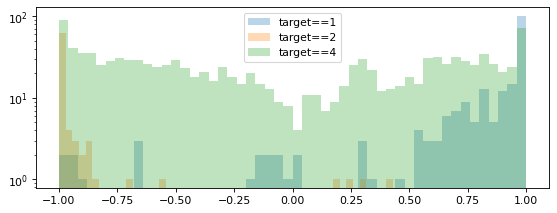

In [6]:
def _(features):
    fig, axs = plot.fig_init('features', (1, 1), 3, width=8.5, dpi=78)
    axs = axs.flatten()
    alpha = 0.3
        
    axs[0].hist(features.outputs[features.target == 1], 
                density=False, log=True, bins=50,
                label=f'target==1', alpha=alpha)
    axs[0].hist(features.outputs[features.target == 2], 
                density=False, log=True, bins=50,
                label=f'target==2', alpha=alpha)
    axs[0].hist(features.outputs[features.target == 4], 
                density=False, log=True, bins=50,
                label=f'target==4', alpha=alpha)
    
    axs[0].legend()
    plt.show()
_(bridge)

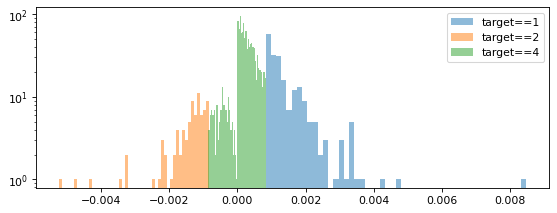

In [7]:
def _(features):
    fig, axs = plot.fig_init('features', (1, 1), 3, width=8.5, dpi=78)
    axs = axs.flatten()
    alpha = 0.5
        
    axs[0].hist(features.virtual[features.target == 1], 
                density=False, log=True, bins=50,
                label=f'target==1', alpha=alpha)
    axs[0].hist(features.virtual[features.target == 2], 
                density=False, log=True, bins=50,
                label=f'target==2', alpha=alpha)
    axs[0].hist(features.virtual[features.target == 4], 
                density=False, log=True, bins=50,
                label=f'target==4', alpha=alpha)
    
    axs[0].legend()
    plt.show()
_(bridge)

In [8]:
importlib.reload(plot)

<module 'szxxx.common.plotting' from 'C:\\Users\\stefa\\Documents\\workspaces\\szx81\\szxxx\\src\\szxxx\\common\\plotting.py'>

In [ ]:
class ViewInput:
    def __init__(self, features, target, advice, 
                 n_neighbors=5, min_dist=0.9,):
        n_components = 3
        alpha = 1
        umap = UMAP(
                    n_neighbors=n_neighbors,
                    min_dist=min_dist,
                    n_components=n_components, 
                    metric='euclidean',
                    init='pca',
                    n_jobs=1,
                    random_state=42,
                    ).fit(features)
        umap_emb = umap.embedding_
        plot.plot_array(
            plots=[
                plot.ScatterCm(
                    X=umap_emb,
                    c=target,
                    cmap='plasma',
                    label='outputs',
                    s=0.5,
                    alpha=alpha,
                    title='Bridge outputs',
                    count=2000,
                    projection=n_components,
                ),
                plot.ScatterCm(
                    X=umap_emb,
                    c=virtual,
                    cmap='plasma',
                    label='virtual',
                    s=0.5,
                    alpha=alpha,
                    title='virtual profit',
                    count=2000,
                    projection=n_components,
                ),
            ],
            rows=1,
            clms=2,
            size=(8.5, 3),
        )
    def caption(self):
        md(f'''
**UMAP** discovers the topology of a given multidimensional vector set and reproduce it in a lower dimension. The accuracy of the process can be adjusted with the parameters `n_neighbors` and `min_dist`.
           
The consistency of the data distribution is a good prognostic. Still better if clusters are differently labeled - colored.
           
The figure above represent featuring of the `Bridge`. The titles and labels refer to the color labeling of the data

''')

vi = ViewInput(features, target, advice, n_neighbors=5, min_dist=0.9)
vi.caption()

In [10]:
from szxxx.features.features import FeaturesDto, Features
from szxxx.features.piecewise import PiecewiseDto, Piecewise
from szxxx.tokenizer.tokenizer import Tokenizer 

In [11]:

md('##`Piecewise` feature extractor')

In [12]:

from szxxx.config import Config
Config('szx81')

features=tools.load(
        'piecewise;mean_len-15;seg_size-10;idx_step-1;', verbose=False)
tokenizer=Tokenizer(features, {
                Piecewise.TIME: (4, 'lambda x: np.log10(x + 1.)'), 
                Piecewise.VALUE: (8, None),
                Piecewise.SLOPE: (8, None),
                Piecewise.NOISE: (8, None),
                Piecewise.VOLUME: (8, 'lambda x: np.log10(x + 1.)'),
            }
)

In [13]:
# 
segments = np.array(features.segments) # (858, 10, 6)
segments = np.random.permutation(segments)
features_mod = tokenizer.modify_features(segments.T)
features_norm = tokenizer.norm_features(features_mod).T

In [40]:

profit_min = 12e-4
seq_len = 0
virtual = []
outputs = []
features = []
preds = forecast.predictions
for feat in features_norm[:40000]:
    stamp = feat[-1][-1]
    if stamp in preds:
        pred = preds[stamp]
        features.append(feat.T[:-1].T[seq_len:].flatten())
        v = pred[1]
        if v > profit_min:
            outputs.append(UP)
        elif -profit_min > v:
            outputs.append(DOWN)
        else:
            outputs.append(WAIT)
        virtual.append(v)
        
features = array(features)
features[np.isnan(features)] = 0.5
virtual = array(virtual)
outputs = array(outputs)

wait_mask = outputs == WAIT

features_wait = features[wait_mask]
cut = len(features[~wait_mask]) // 3
features_adj = np.concatenate((features[~wait_mask], features[wait_mask][:cut]))
virtual_adj = np.concatenate((virtual[~wait_mask], virtual[wait_mask][:cut]))
target_adj = np.concatenate((outputs[~wait_mask], outputs[wait_mask][:cut]))

In [41]:
set(target_adj)

{0, 1, 2}

In [42]:
# class ViewPiecewise
class PiecewiseUmap:
    def __init__(self, features, target, virtual,
                 n_neighbors=5, min_dist=0.9,):
        n_components = 3
        alpha = 0.99
        s = 3.5
        features = features[target != WAIT]
        umap = UMAP(
                    n_neighbors=n_neighbors,
                    min_dist=min_dist,
                    n_components=n_components, 
                    metric='euclidean',
                    init='pca',
                    n_jobs=1,
                    random_state=42,
                    ).fit(features)
        umap_emb = umap.embedding_

        plot.plot_array(
            plots=[
                plot.Scatter(
                    X=umap_emb,
                    c=target,
                    cmap='tab10',
                    label=DIR_MAP,
                    s=s,
                    alpha=alpha,
                    title='target',
                    count=2000,
                    projection=n_components,
                ),
                # plot.ScatterCm(
                #     X=umap_emb[np.abs(virtual < 40e-4)],
                #     c=virtual[np.abs(virtual < 40e-4)],
                #     cmap='viridis', #'Reds', #'magma', # 'plasma',
                #     label='virtual profit',
                #     s=s,
                #     alpha=alpha,
                #     title='virtual profit',
                #     count=2000,
                #     projection=n_components,
                # ),
            ],
            rows=1,
            clms=1,
            size=(8.5, 8.5),
        )
    def caption(self):
        md(f'''
**UMAP** discovers the topology of a given multidimensional vector set and reproduce it in a lower dimension. The accuracy of the process can be adjusted with the parameters `n_neighbors` and `min_dist`.
           
The figure above represent featuring by the `Piecewise`. The titles and labels refer to the color labeling of the data
           
The population of the `WAIT` component is suppressed in order to make the active cases visible.

''')

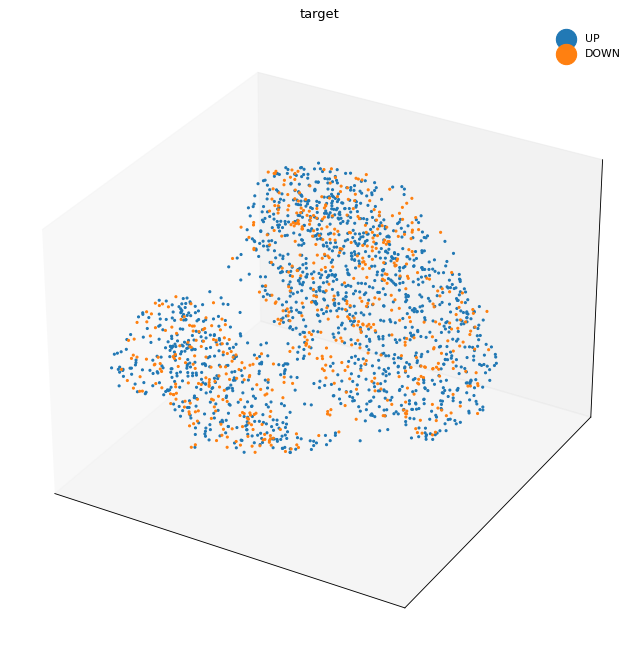

In [43]:
# ViewPiecewise
vi = PiecewiseUmap(features_adj, target_adj, virtual_adj, 
                   n_neighbors=15, min_dist=0.2)
vi.caption()

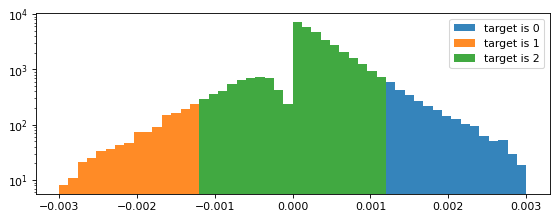

In [44]:
def _():
    fig, axs = plot.fig_init('features1', (1, 1), 3, width=8.5, dpi=78)
    axs = axs.flatten()
    alpha = 0.9
    
    axs[0].hist(virtual[outputs == 0], 
                density=False, log=True, bins=50, range=(-0.003, 0.003),
                label=f'target is {0}', alpha=alpha)
    axs[0].hist(virtual[outputs == 1], 
                density=False, log=True, bins=50, range=(-0.003, 0.003),
                label=f'target is {1}', alpha=alpha)
    axs[0].hist(virtual[outputs == 2], 
                density=False, log=True, bins=50, range=(-0.003, 0.003),
                label=f'target is {2}', alpha=alpha) 
       
    # axs[0].hist(virtual, 
    #             density=True, bins=50, range=(-0.003, 0.003),
    #             label=f'virtual all', alpha=alpha / 2)    
    axs[0].legend()
      

    plt.show()
_()

In [45]:
set(outputs)

{0, 1, 2}